# 01 — Attribute Labels for v1.0-trainval Subset
## Multi-Attribute Scene Classification on nuScenes

**Purpose:** Generate four target labels for every keyframe in the 150 selected scenes.

### Target labels

| Attribute | Classes | Source |
|---|---|---|
| `time_of_day` | day / night | Scene description keywords |
| `weather` | clear / rain | Scene description keywords |
| `vehicle_density` | low / medium / high | Tertile-binned forward-cone vehicle count |
| `vru_present` | absent / present | Forward-cone VRU count ≥ 1 |

### Methodology notes

- **Forward cone**: ±30° half-angle, 50 m max range (same as Stage 1)
- **Vehicle categories**: cars, trucks, buses, trailers, construction vehicles (matches Stage 1)
- **VRU categories**: pedestrians, bicycles, motorcycles (matches Stage 1)
- **Tertile thresholds**: **computed fresh from this 150-scene subset** (NOT reused from v1.0-mini)
  - Trade-off: balanced classes within Stage 2, but "high density" means slightly different things in mini vs subset

### Inputs
- `data/processed/v1.0-trainval/selected_scenes.csv` (from 00b)
- `data/processed/v1.0-trainval/metadata/sample_metadata.csv` (from 00a — contains time_of_day, weather)
- nuScenes devkit (for forward-cone object counting)

### Outputs
- `data/processed/v1.0-trainval/labels/attribute_labels.csv` (one row per keyframe)
- `data/processed/v1.0-trainval/labels/attribute_thresholds.json` (tertile cutoffs)
- `data/processed/v1.0-trainval/labels/label_distribution.json` (summary)


## 0. Setup

In [1]:
import os
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


## 0.1 Locate Project Root

In [2]:
def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError(f'Could not find project root from {p}')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 1. Configuration

In [3]:
DATASET_VERSION = 'v1.0-trainval'

# Paths
NUSCENES_BASE = Path('data/nuscenes') / DATASET_VERSION
PROCESSED_DIR = Path('data/processed') / DATASET_VERSION
LABELS_DIR    = PROCESSED_DIR / 'labels'
FIG_DIR       = Path('results') / DATASET_VERSION / 'figures'

LABELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Auto-detect metadata location
def find_metadata_dir(base, version):
    candidates = [base / version, base / f'{version}_meta' / version, base]
    for c in candidates:
        if c.exists() and len(list(c.glob('*.json'))) >= 10:
            return c
    raise FileNotFoundError(f'Could not find metadata under {base}')

METADATA_DIR = find_metadata_dir(NUSCENES_BASE, DATASET_VERSION)

# Forward cone parameters (must match Stage 1)
FORWARD_CONE_ANGLE_DEG = 30
FORWARD_CONE_RANGE_M = 50

# Object categories
VEHICLE_PREFIXES = ('vehicle.car', 'vehicle.truck', 'vehicle.bus',
                     'vehicle.trailer', 'vehicle.construction')
VRU_PREFIXES = ('human.pedestrian', 'vehicle.bicycle', 'vehicle.motorcycle')

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'METADATA_DIR    = {METADATA_DIR}')
print(f'LABELS_DIR      = {LABELS_DIR}')
print(f'Forward cone:   ±{FORWARD_CONE_ANGLE_DEG}°, {FORWARD_CONE_RANGE_M} m')

DATASET_VERSION = v1.0-trainval
METADATA_DIR    = data\nuscenes\v1.0-trainval\v1.0-trainval_meta\v1.0-trainval
LABELS_DIR      = data\processed\v1.0-trainval\labels
Forward cone:   ±30°, 50 m


## 2. Load nuScenes Devkit

In [4]:
# Determine correct dataroot for devkit
DATAROOT = METADATA_DIR.parent
print(f'Loading nuScenes devkit (dataroot={DATAROOT})...')
nusc = NuScenes(version=DATASET_VERSION, dataroot=str(DATAROOT), verbose=False)
print(f'✓ Loaded {len(nusc.scene)} scenes, {len(nusc.sample)} keyframes')

Loading nuScenes devkit (dataroot=data\nuscenes\v1.0-trainval\v1.0-trainval_meta)...
✓ Loaded 850 scenes, 34149 keyframes


## 3. Load Selected Scenes

In [5]:
selected_path = PROCESSED_DIR / 'selected_scenes.csv'
if not selected_path.exists():
    raise FileNotFoundError(f'Run 00b_scene_selection.ipynb first to produce {selected_path}')

df_selected = pd.read_csv(selected_path)
selected_scene_tokens = set(df_selected['scene_token'].tolist())
print(f'Loaded {len(df_selected)} selected scenes')
print(f'\nStrata breakdown:')
print(df_selected.groupby(['time_of_day', 'weather']).size())

Loaded 150 selected scenes

Strata breakdown:
time_of_day  weather
day          clear      95
             rain       25
night        clear      25
             rain        5
dtype: int64


## 4. Build Per-Keyframe DataFrame

Get every keyframe (sample) that belongs to one of our 150 selected scenes.

In [6]:
rows = []
for sample in nusc.sample:
    if sample['scene_token'] not in selected_scene_tokens:
        continue

    # Get CAM_FRONT info
    cam_token = sample['data']['CAM_FRONT']
    cam_data = nusc.get('sample_data', cam_token)

    # Find this scene's metadata
    scene_meta = df_selected[df_selected['scene_token'] == sample['scene_token']].iloc[0]

    rows.append({
        'sample_token':   sample['token'],
        'scene_token':    sample['scene_token'],
        'scene_name':     scene_meta['scene_name'],
        'cam_front_token': cam_token,
        'filename':       cam_data['filename'],
        'timestamp':      sample['timestamp'],
        'time_of_day':    scene_meta['time_of_day'],
        'weather':        scene_meta['weather'],
        'location':       scene_meta['location'],
    })

df = pd.DataFrame(rows)
print(f'Total keyframes from 150 selected scenes: {len(df)}')
print(f'Mean keyframes per scene: {len(df) / len(df_selected):.1f}')

Total keyframes from 150 selected scenes: 6021
Mean keyframes per scene: 40.1


## 5. Compute Forward-Cone Object Counts

For each keyframe, count vehicles and VRUs visible in the forward cone. This is the slow step (~10-20 min).

In [7]:
def get_ego_pose_for_sample(nusc, sample_token):
    sample = nusc.get('sample', sample_token)
    cam_token = sample['data']['CAM_FRONT']
    cam_data = nusc.get('sample_data', cam_token)
    ego_pose = nusc.get('ego_pose', cam_data['ego_pose_token'])
    return np.array(ego_pose['translation']), Quaternion(ego_pose['rotation'])

def is_in_forward_cone(ann_translation, ego_translation, ego_rotation):
    rel = np.array(ann_translation) - ego_translation
    rel_ego = ego_rotation.inverse.rotate(rel)
    x, y = rel_ego[0], rel_ego[1]
    if x <= 0:
        return False
    dist = np.sqrt(x ** 2 + y ** 2)
    if dist > FORWARD_CONE_RANGE_M:
        return False
    angle = np.degrees(np.arctan2(abs(y), x))
    return angle <= FORWARD_CONE_ANGLE_DEG

print('Computing forward-cone object counts...')
veh_counts = np.zeros(len(df), dtype=np.int32)
vru_counts = np.zeros(len(df), dtype=np.int32)

for i, sample_token in enumerate(tqdm(df['sample_token'].tolist(), desc='Keyframes')):
    sample = nusc.get('sample', sample_token)
    ego_t, ego_r = get_ego_pose_for_sample(nusc, sample_token)
    veh_count, vru_count = 0, 0
    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        cat = ann['category_name']
        if not (cat.startswith(VEHICLE_PREFIXES) or cat.startswith(VRU_PREFIXES)):
            continue
        if not is_in_forward_cone(ann['translation'], ego_t, ego_r):
            continue
        if cat.startswith(VEHICLE_PREFIXES):
            veh_count += 1
        if cat.startswith(VRU_PREFIXES):
            vru_count += 1
    veh_counts[i] = veh_count
    vru_counts[i] = vru_count

df['veh_count_fwd'] = veh_counts
df['vru_count_fwd'] = vru_counts

print(f'\n=== Vehicle count distribution (forward cone) ===')
print(df['veh_count_fwd'].describe())
print(f'\n=== VRU count distribution (forward cone) ===')
print(df['vru_count_fwd'].describe())

Computing forward-cone object counts...


Keyframes:   0%|          | 0/6021 [00:00<?, ?it/s]


=== Vehicle count distribution (forward cone) ===
count    6021.000000
mean        3.192327
std         3.105383
min         0.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        19.000000
Name: veh_count_fwd, dtype: float64

=== VRU count distribution (forward cone) ===
count    6021.000000
mean        1.264740
std         2.221161
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        20.000000
Name: vru_count_fwd, dtype: float64


## 6. Generate `vru_present` Label

In [8]:
df['vru_present'] = np.where(df['vru_count_fwd'] >= 1, 'present', 'absent')

print('VRU presence distribution:')
print(df['vru_present'].value_counts())
print()
n_present = (df['vru_present'] == 'present').sum()
n_absent = (df['vru_present'] == 'absent').sum()
print(f'  present: {n_present} ({n_present / len(df) * 100:.1f}%)')
print(f'  absent:  {n_absent} ({n_absent / len(df) * 100:.1f}%)')

VRU presence distribution:
vru_present
absent     3201
present    2820
Name: count, dtype: int64

  present: 2820 (46.8%)
  absent:  3201 (53.2%)


## 7. Compute Fresh Tertile Thresholds for `vehicle_density`

Option B: thresholds computed from this 150-scene subset's data.

In [9]:
# Tertile thresholds (computed fresh from this subset)
tertile_low_high  = float(df['veh_count_fwd'].quantile(1/3))
tertile_med_high  = float(df['veh_count_fwd'].quantile(2/3))

print(f'Tertile thresholds (computed fresh from this subset):')
print(f'  low   bin: veh_count ≤ {tertile_low_high:.1f}')
print(f'  medium bin: {tertile_low_high:.1f} < veh_count ≤ {tertile_med_high:.1f}')
print(f'  high  bin: veh_count > {tertile_med_high:.1f}')

def bin_density(c, lo, hi):
    if c <= lo: return 'low'
    if c <= hi: return 'medium'
    return 'high'

df['vehicle_density'] = df['veh_count_fwd'].apply(
    lambda c: bin_density(c, tertile_low_high, tertile_med_high))

print('\nVehicle density distribution:')
print(df['vehicle_density'].value_counts())
print()
for cls in ['low', 'medium', 'high']:
    n = (df['vehicle_density'] == cls).sum()
    print(f'  {cls:6s}: {n} ({n / len(df) * 100:.1f}%)')

Tertile thresholds (computed fresh from this subset):
  low   bin: veh_count ≤ 1.0
  medium bin: 1.0 < veh_count ≤ 4.0
  high  bin: veh_count > 4.0

Vehicle density distribution:
vehicle_density
medium    2241
low       2193
high      1587
Name: count, dtype: int64

  low   : 2193 (36.4%)
  medium: 2241 (37.2%)
  high  : 1587 (26.4%)


## 8. Save Thresholds and Labels

In [10]:
# Save thresholds for reference and downstream use
thresholds = {
    'tertile_low_high':  tertile_low_high,
    'tertile_med_high':  tertile_med_high,
    'forward_cone_angle_deg': FORWARD_CONE_ANGLE_DEG,
    'forward_cone_range_m':   FORWARD_CONE_RANGE_M,
    'n_keyframes_used': int(len(df)),
    'computed_from':    DATASET_VERSION + ' 150-scene subset',
    'note': 'These thresholds are computed fresh from the subset (Option B). '
             'They differ from v1.0-mini thresholds — direct vehicle_density '
             'accuracy comparison between mini and subset is approximate.',
}
with open(LABELS_DIR / 'attribute_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print(f'Saved → {LABELS_DIR / "attribute_thresholds.json"}')

# Save the full attribute labels CSV
out_cols = [
    'sample_token', 'scene_token', 'scene_name', 'filename',
    'time_of_day', 'weather', 'location',
    'veh_count_fwd', 'vru_count_fwd',
    'vehicle_density', 'vru_present',
    'timestamp',
]
df[out_cols].to_csv(LABELS_DIR / 'attribute_labels.csv', index=False)
print(f'Saved → {LABELS_DIR / "attribute_labels.csv"}  ({len(df)} rows)')

Saved → data\processed\v1.0-trainval\labels\attribute_thresholds.json
Saved → data\processed\v1.0-trainval\labels\attribute_labels.csv  (6021 rows)


## 9. Verify Label Distributions

Sanity check that all four attributes have reasonable class balance.

In [11]:
print('=' * 70)
print('LABEL DISTRIBUTION VERIFICATION')
print('=' * 70)

attrs_info = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}

distributions = {}
for attr, classes in attrs_info.items():
    counts = df[attr].value_counts()
    total = len(df)
    print(f'\n{attr}:')
    dist = {}
    for cls in classes:
        n = counts.get(cls, 0)
        pct = n / total * 100
        flag = '✓' if 10 <= pct <= 90 else '⚠️'
        print(f'  {cls:8s}: {n:5d} ({pct:5.1f}%) {flag}')
        dist[cls] = int(n)
    distributions[attr] = dist

LABEL DISTRIBUTION VERIFICATION

time_of_day:
  day     :  4815 ( 80.0%) ✓
  night   :  1206 ( 20.0%) ✓

weather:
  clear   :  4813 ( 79.9%) ✓
  rain    :  1208 ( 20.1%) ✓

vehicle_density:
  low     :  2193 ( 36.4%) ✓
  medium  :  2241 ( 37.2%) ✓
  high    :  1587 ( 26.4%) ✓

vru_present:
  absent  :  3201 ( 53.2%) ✓
  present :  2820 ( 46.8%) ✓


In [12]:
# Save distribution summary
summary = {
    'dataset_version': DATASET_VERSION,
    'n_scenes':       int(len(df_selected)),
    'n_keyframes':    int(len(df)),
    'distributions':  distributions,
    'tertile_thresholds': {
        'tertile_low_high': tertile_low_high,
        'tertile_med_high': tertile_med_high,
    },
}
with open(LABELS_DIR / 'label_distribution.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved → {LABELS_DIR / "label_distribution.json"}')
print()
print(json.dumps(summary, indent=2))

Saved → data\processed\v1.0-trainval\labels\label_distribution.json

{
  "dataset_version": "v1.0-trainval",
  "n_scenes": 150,
  "n_keyframes": 6021,
  "distributions": {
    "time_of_day": {
      "day": 4815,
      "night": 1206
    },
    "weather": {
      "clear": 4813,
      "rain": 1208
    },
    "vehicle_density": {
      "low": 2193,
      "medium": 2241,
      "high": 1587
    },
    "vru_present": {
      "absent": 3201,
      "present": 2820
    }
  },
  "tertile_thresholds": {
    "tertile_low_high": 1.0,
    "tertile_med_high": 4.0
  }
}


## 9b. Cross-Attribute Co-Occurrence (Cramér's V)

In [13]:
# ============================================================
# Cross-Attribute Co-Occurrence (Cramér's V) — subset
# Mirrors the mini-stage analysis for a fair, consistent study
# ============================================================
from itertools import combinations

def cramers_v(x, y):
    """Cramér's V — categorical association strength, range [0, 1]."""
    confusion = pd.crosstab(x, y)
    chi2 = ((confusion - (confusion.sum(axis=1).values[:, None] * confusion.sum(axis=0).values / confusion.values.sum())) ** 2 /
            (confusion.sum(axis=1).values[:, None] * confusion.sum(axis=0).values / confusion.values.sum())).sum().sum()
    n = confusion.values.sum()
    r, k = confusion.shape
    denom = n * (min(r, k) - 1)
    return float(np.sqrt(chi2 / denom)) if denom > 0 else 0.0

attributes = list(attrs_info.keys())

print("Pairwise Cramér's V (0 = independent, 1 = perfectly associated) — 150-scene subset:")
cramers_results = {}
for a, b in combinations(attributes, 2):
    v = cramers_v(df[a], df[b])
    cramers_results[f'{a}__{b}'] = round(v, 3)
    print(f'  {a:18s} ↔ {b:18s}: {v:.3f}')

Pairwise Cramér's V (0 = independent, 1 = perfectly associated) — 150-scene subset:
  time_of_day        ↔ weather           : 0.042
  time_of_day        ↔ vehicle_density   : 0.108
  time_of_day        ↔ vru_present       : 0.094
  weather            ↔ vehicle_density   : 0.120
  weather            ↔ vru_present       : 0.071
  vehicle_density    ↔ vru_present       : 0.118


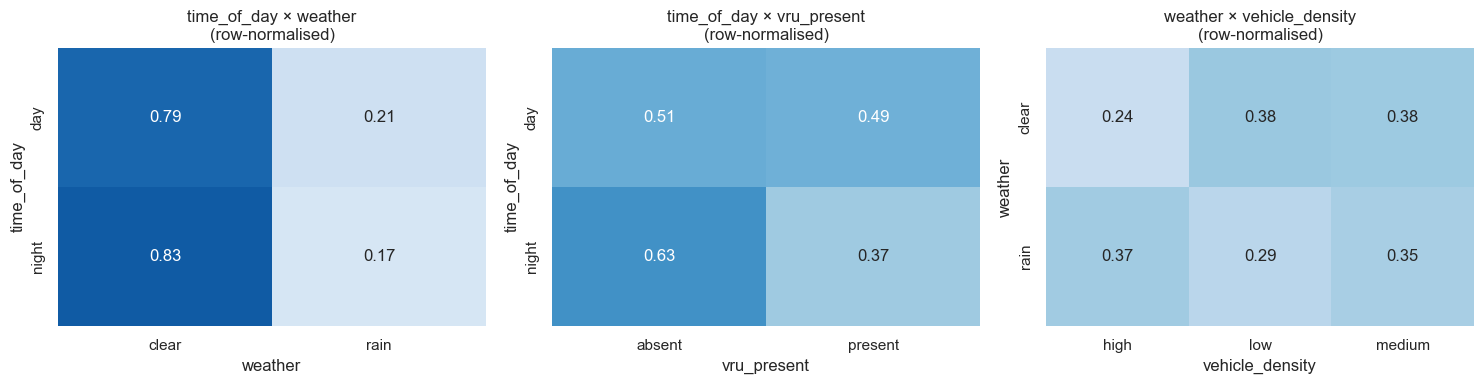

Saved → results\v1.0-trainval\figures\attribute_cooccurrence.png


In [14]:
# Visualise key attribute pairs (row-normalised contingency)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('time_of_day', 'weather'),
         ('time_of_day', 'vru_present'),
         ('weather', 'vehicle_density')]
for ax, (a, b) in zip(axes, pairs):
    ct = pd.crosstab(df[a], df[b], normalize='index')
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                ax=ax, cbar=False)
    ax.set_title(f'{a} × {b}\n(row-normalised)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'attribute_cooccurrence.png', bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "attribute_cooccurrence.png"}')

## 9c. Per-Scene Class Coverage

In [15]:
# ============================================================
# Per-Scene Class Coverage — subset
# How many of the 150 scenes contain each class
# ============================================================
print(f'Number of unique scenes: {df["scene_token"].nunique()}')
print(f'\nClasses by number of scenes containing them:')
scene_coverage = {}
for attr, classes in attrs_info.items():
    scene_class_pairs = df[['scene_token', attr]].drop_duplicates()
    counts = scene_class_pairs[attr].value_counts().reindex(classes).fillna(0).astype(int)
    print(f'  {attr}:')
    scene_coverage[attr] = {}
    for cls, n_scenes in counts.items():
        flag = '⚠ THIN' if n_scenes < 2 else 'ok'
        print(f'    {cls:10s}: {n_scenes:2d} scenes  [{flag}]')
        scene_coverage[attr][cls] = int(n_scenes)

Number of unique scenes: 150

Classes by number of scenes containing them:
  time_of_day:
    day       : 120 scenes  [ok]
    night     : 30 scenes  [ok]
  weather:
    clear     : 120 scenes  [ok]
    rain      : 30 scenes  [ok]
  vehicle_density:
    low       : 114 scenes  [ok]
    medium    : 136 scenes  [ok]
    high      : 94 scenes  [ok]
  vru_present:
    absent    : 135 scenes  [ok]
    present   : 129 scenes  [ok]


## 10. Visualize Distributions

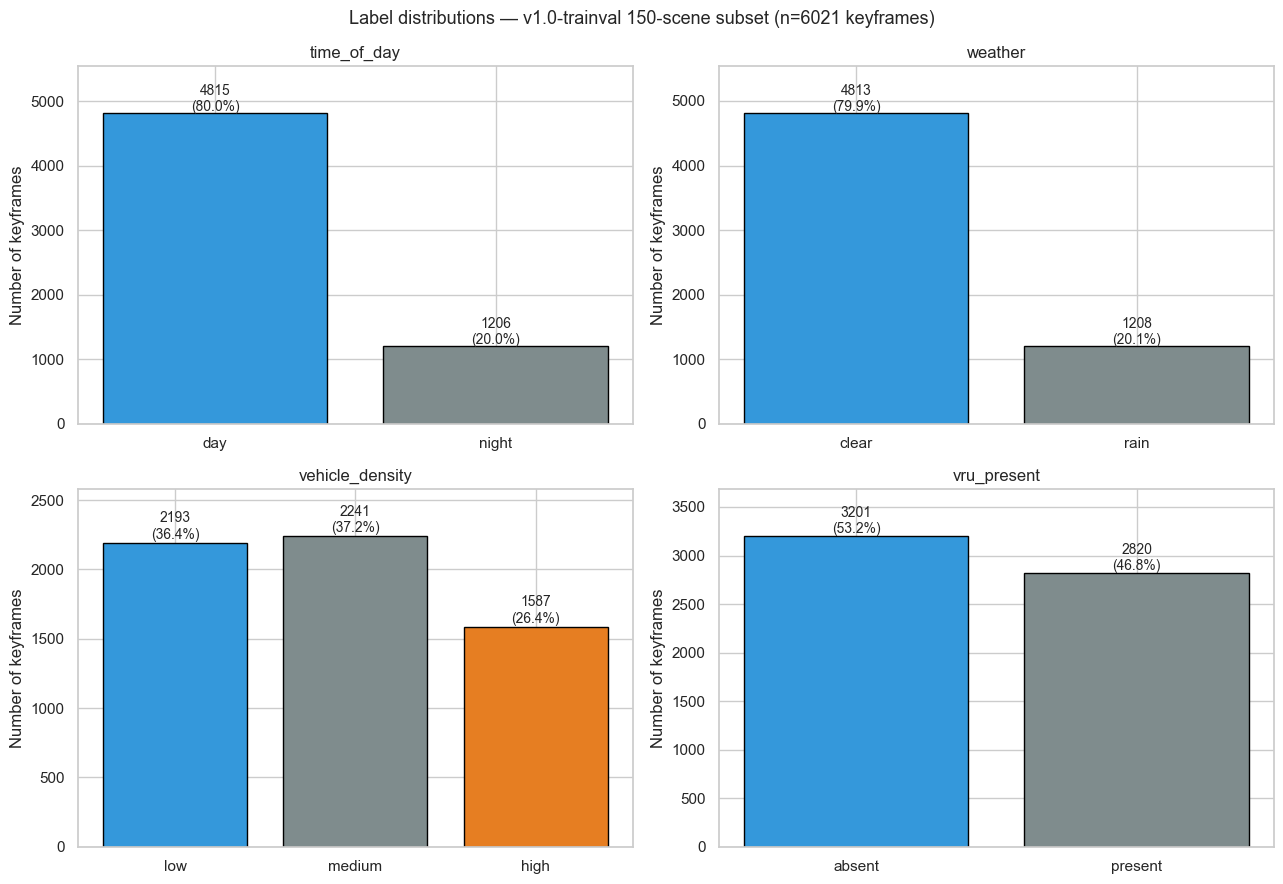

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

colors = ['#3498db', '#7f8c8d', '#e67e22', '#2ecc71']
for i, (attr, classes) in enumerate(attrs_info.items()):
    ax = axes[i // 2, i % 2]
    counts = [df[attr].eq(cls).sum() for cls in classes]
    bars = ax.bar(classes, counts, color=colors[:len(classes)], edgecolor='black')
    for bar, n in zip(bars, counts):
        pct = n / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
                 f'{n}\n({pct:.1f}%)', ha='center', fontsize=10)
    ax.set_title(f'{attr}')
    ax.set_ylabel('Number of keyframes')
    ax.set_ylim(0, max(counts) * 1.15)

plt.suptitle(f'Label distributions — v1.0-trainval 150-scene subset (n={len(df)} keyframes)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_distributions.png', bbox_inches='tight')
plt.show()

## 11. Comparison with v1.0-mini

In [17]:
# Try to load mini's label distribution
mini_labels_paths = [
    Path('data/processed/v1.0-mini/labels/attribute_labels.csv'),
    Path('data/labels/attribute_labels.csv'),  # legacy
]
df_mini = None
for p in mini_labels_paths:
    if p.exists():
        df_mini = pd.read_csv(p)
        print(f'Loaded v1.0-mini labels: {p} ({len(df_mini)} rows)')
        break

if df_mini is not None:
    print(f'\n=== MINI vs SUBSET label distribution ===\n')
    for attr, classes in attrs_info.items():
        if attr not in df_mini.columns:
            continue
        print(f'{attr}:')
        for cls in classes:
            mini_pct = (df_mini[attr] == cls).mean() * 100
            sub_pct  = (df[attr] == cls).mean() * 100
            delta = sub_pct - mini_pct
            arrow = '↑' if delta > 1 else ('↓' if delta < -1 else '·')
            print(f'  {cls:8s}: mini {mini_pct:5.1f}%  vs  subset {sub_pct:5.1f}%  ({arrow}{abs(delta):+.1f}%)')
        print()
else:
    print('v1.0-mini labels not found — comparison skipped')

Loaded v1.0-mini labels: data\processed\v1.0-mini\labels\attribute_labels.csv (404 rows)

=== MINI vs SUBSET label distribution ===

time_of_day:
  day     : mini  70.0%  vs  subset  80.0%  (↑+9.9%)
  night   : mini  30.0%  vs  subset  20.0%  (↓+9.9%)

weather:
  clear   : mini  90.1%  vs  subset  79.9%  (↓+10.2%)
  rain    : mini   9.9%  vs  subset  20.1%  (↑+10.2%)

vehicle_density:
  low     : mini  33.4%  vs  subset  36.4%  (↑+3.0%)
  medium  : mini  33.2%  vs  subset  37.2%  (↑+4.1%)
  high    : mini  33.4%  vs  subset  26.4%  (↓+7.1%)

vru_present:
  absent  : mini  39.9%  vs  subset  53.2%  (↑+13.3%)
  present : mini  60.1%  vs  subset  46.8%  (↓+13.3%)



## 12. Next Steps

In [18]:
print('=' * 70)
print('ATTRIBUTE LABELING COMPLETE')
print('=' * 70)
print()
print(f'Total keyframes labeled: {len(df)}')
print(f'Output: {LABELS_DIR / "attribute_labels.csv"}')
print()
print('Next notebook: 02_image_features.ipynb')
print('  - Extracts HOG, color histogram, LBP, photometric features')
print('  - Runtime: ~30-45 min for 6,021 keyframes')

ATTRIBUTE LABELING COMPLETE

Total keyframes labeled: 6021
Output: data\processed\v1.0-trainval\labels\attribute_labels.csv

Next notebook: 02_image_features.ipynb
  - Extracts HOG, color histogram, LBP, photometric features
  - Runtime: ~30-45 min for 6,021 keyframes
